# 架構 H — 漸進式 MVP（不平行）

這是「部門開發自動化」架構比較(見 `notebooks/arch/README.md`)裡的選項 H：**先不做平行 slice、
不做 worktree 隔離、不做分波合併——一個 change 就一個 coding agent 從頭做到尾**,只留下
「對齊需求」跟「人工驗收」這兩個檢查點。這是風險最低的起始版本,先驗證「壓縮成兩次人工介入」
這個核心迴圈本身好不好用,平行化(架構 A)之後再疊上去,不需要一次到位。

## 這一版更新了什麼(討論後加上去的兩件事)

跟第一版比,這裡補了兩個東西,起因是討論到「`test_agent`/`review_agent` 後面要不要接一個決策
關卡」跟「使用者要不要每一輪都被告知進度」這兩個問題:

1. **加了 `review_gate`**——原本 H 是不管 test/review 結果如何,每次都直接卡進
   `human_checkpoint`,由人自己判斷要不要重來。現在改成:test/review 都過才進
   `human_checkpoint`;沒過就自動帶著意見回頭找 `code_agent` 重做,最多兩輪，兩輪都沒過才
   交給人——**這是跟架構 A 一樣的確定性判斷（純 Python 布林邏輯，不是 agent 自己拿主意）**，
   不是新增一個「決策 agent」。這個改動讓 H 不再是「每次失敗都要麻煩人」，跟 A 站在同一個
   起跑點上。
2. **加了進度通知**——每一輪 `code_agent` 做完、`review_gate` 判斷完，都會順手把一則進度
   訊息寫進 `store`（不是 `interrupt()`）。這是**不會打斷執行的旁路通知**：使用者隨時可以
   查詢「現在到哪了」，但不需要因為這個通知而停下來等人回應——真正需要人做決定的，還是只有
   對齊需求跟最終核准這兩個點。

## 人工介入次數（每個 change）：**2 次**

跟架構 A 一樣是對齊一次、驗收一次——這是這整套設計的底線,不因為省略平行化就打折扣，加了
`review_gate` 之後這個數字比第一版更站得住腳，因為現在失敗重試不會額外多打擾人。差別在
**吞吐量**：一個 change 裡如果本來能拆成好幾個互不相干的 slice 平行做,這裡還是會序列化
一個一個做完,單一 change 的完成時間會比架構 A 長。用一句話講清楚取捨:**這個版本用「做得慢
一點」換「複雜度低很多、更快能讓部門開始用」**。

## 什麼時候該選這個而不是架構 A

- 部門還沒實際用過這種「壓縮成兩次核准」的工作模式,想先驗證使用者(工程師)習不習慣、
  信不信任自動跑完的結果,再決定要不要投入平行化的複雜度。
- 大部分 change 本來就小,拆 slice 平行化的效益有限,加這層複雜度不划算。
- 團隊還沒有人讀熟架構 A 那套「touches 宣告→分波→合併衝突降級」的邏輯,先上一個好維護、
  好排查的版本，比一次上全套但没人看得懂全部分支划算。

> 不需要 API key，節點都是純 Python 假邏輯，離線就能跑完。

In [1]:
import sys
from typing import Literal, TypedDict

sys.path.insert(0, "..")  # 這份 notebook 在 notebooks/arch/ 底下，_graph_viz.py 在上一層
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.config import get_store
from langgraph.graph import END, START, StateGraph
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command, interrupt

from _graph_viz import show_graph

## State

沒有 `slices`/`waves`/reducer——只有一個 `code_agent` 在寫,`code_changes` 直接覆蓋就好,
不需要像架構 A 那樣用 `operator.add` 合併多個平行寫入者的結果。這是這個版本比架構 A 簡單
的具體證據，不是憑空講「比較簡單」。`review_rounds`/`review_feedback` 是這次加 `review_gate`
才需要的兩個欄位，跟架構 A 的做法一致。

In [2]:
class DevWorkflowState(TypedDict):
    requirement: str
    code_changes: str
    test_report: str
    review_report: str
    review_rounds: int    # 這一輪累積被打回重做幾次
    review_feedback: str  # 上一輪 review 的意見，重派時要帶著這個一起丟給 code_agent

## 節點

七個節點——比第一版多了 `review_gate`（決定要重做還是交給人），但仍然沒有
`plan_slices`/`plan_waves`/`dispatch_wave`/`merge_wave`/`resolve_conflict`/`advance_or_finish`
——這幾個是架構 A 為了平行化才需要的，這裡繼續省略。`report_progress` 不是一個獨立節點，是一個
被 `code_agent`/`review_gate` 呼叫的小工具函式——上一輪討論已經定案：通知不該用 `interrupt()`
做（那會卡住等人回應），也不該為了通知另外加一個會影響控制流的節點，寫成「順手做的副作用」
最單純。

In [3]:
def report_progress(config: RunnableConfig, note: str) -> None:
    # 非阻塞的旁路通知：只是把一則訊息追加進 store，不是 interrupt()。
    # 使用者可以隨時查詢（見下面 demo 的 store.get(...)），但這一步本身不會讓 graph 停下來
    # 等任何人回應——「通知」跟「要求人做決定」是兩件事，不能共用同一個機制。
    store = get_store()
    thread_id = config["configurable"]["thread_id"]
    key = ("workflow", thread_id)
    existing = store.get(key, "progress")
    log = list(existing.value["log"]) if existing else []
    log.append(note)
    store.put(key, "progress", {"log": log})


def align_requirements(state: DevWorkflowState, config: RunnableConfig) -> dict:
    store = get_store()
    thread_id = config["configurable"]["thread_id"]
    feedback = store.get(("workflow", thread_id), "last_feedback")

    requirement = state.get("requirement") or "（示意）需求描述"
    if feedback:
        requirement += f"（依上一輪回饋調整：{feedback.value['reason']}）"

    return {"requirement": requirement, "review_rounds": 0, "review_feedback": ""}


def code_agent(state: DevWorkflowState, config: RunnableConfig) -> dict:
    # 沒有平行、沒有 worktree 隔離——一個 agent 從頭做到尾。
    # 實務上這裡就是一次 Claude Agent SDK 呼叫，cwd 指到這個 change 專屬的分支。
    # 重試時把上一輪 review 的意見帶進來，不是每次都用同一份 prompt 空重跑。
    note = f"（依上一輪 review 意見調整：{state['review_feedback']}）" if state.get("review_feedback") else ""
    report_progress(config, f"code_agent 完成一輪{note}")
    return {"code_changes": f"{state['requirement']} 已完成{note}（示意，序列化單一 agent）"}


def test_agent(state: DevWorkflowState) -> dict:
    return {"test_report": "PASS（示意）"}


def review_agent(state: DevWorkflowState) -> dict:
    return {"review_report": "PASS（示意）"}


MAX_REVIEW_ROUNDS = 2


def review_gate(
    state: DevWorkflowState, config: RunnableConfig
) -> Command[Literal["code_agent", "human_checkpoint"]]:
    # 跟架構 A 的 review_gate 同一套邏輯：純布林判斷，不是 agent 自己拿主意。
    # test/review 都過 → 交給人做最終驗收；沒過 → 帶著意見回頭找 code_agent 重做，
    # 最多兩輪，兩輪都沒過才交給人（此時是「卡住了」而不是「來驗收」）。
    passed = state["test_report"].startswith("PASS") and state["review_report"].startswith("PASS")
    if passed:
        report_progress(config, "review_gate：test/review 都過，進入人工驗收")
        return Command(goto="human_checkpoint")

    review_rounds = state.get("review_rounds", 0)
    if review_rounds >= MAX_REVIEW_ROUNDS:
        report_progress(config, "review_gate：連續兩輪沒過，交還人工判斷是不是方向錯了")
        return Command(
            update={"review_feedback": "連續兩輪 review 沒過，交還人工判斷是不是方向錯了"},
            goto="human_checkpoint",
        )

    report_progress(config, f"review_gate：第 {review_rounds + 1} 次沒過，帶著意見回頭重做")
    return Command(
        update={"review_rounds": review_rounds + 1, "review_feedback": state["review_report"]},
        goto="code_agent",
    )


def human_checkpoint(
    state: DevWorkflowState, config: RunnableConfig
) -> Command[Literal["align_requirements", "push_or_mr"]]:
    store = get_store()
    thread_id = config["configurable"]["thread_id"]

    decision = interrupt(
        {
            "code_changes": state["code_changes"],
            "test_report": state["test_report"],
            "review_report": state["review_report"],
            "ask": "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}",
        }
    )

    if decision.get("approve"):
        return Command(goto="push_or_mr")

    store.put(("workflow", thread_id), "last_feedback", {"reason": decision.get("reason", "")})
    return Command(goto="align_requirements")


def push_or_mr(state: DevWorkflowState) -> dict:
    return {}

## 組圖

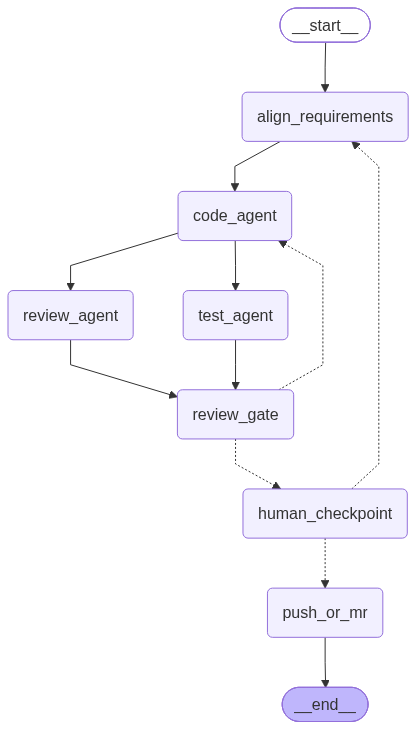

In [4]:
builder = StateGraph(DevWorkflowState)
builder.add_node("align_requirements", align_requirements)
builder.add_node("code_agent", code_agent)
builder.add_node("test_agent", test_agent)
builder.add_node("review_agent", review_agent)
builder.add_node("review_gate", review_gate)
builder.add_node("human_checkpoint", human_checkpoint)
builder.add_node("push_or_mr", push_or_mr)

builder.add_edge(START, "align_requirements")
builder.add_edge("align_requirements", "code_agent")
builder.add_edge("code_agent", "test_agent")
builder.add_edge("code_agent", "review_agent")
builder.add_edge("test_agent", "review_gate")
builder.add_edge("review_agent", "review_gate")
builder.add_edge("push_or_mr", END)

graph = builder.compile(checkpointer=InMemorySaver(), store=InMemoryStore())
show_graph(graph)

## 跑一輪：跟架構 A 一樣的迴圈，但中間沒有分波

同樣示範「有問題 → 重新對齊需求」跟「沒問題 → push/MR」都走得通——這是兩個架構共同的底線，
差別只在中間怎麼把程式碼寫出來。`test_agent`/`review_agent` 這份 sketch 裡永遠回報 PASS，
所以這次跑不會真的觸發 `review_gate` 打回重派那條路（跟架構 A 一樣的限制），但下面會另外
直接呼叫 `review_gate` 驗證那條路的邏輯是對的。

In [5]:
config = {"configurable": {"thread_id": "demo-1"}}

state = graph.invoke(
    {"requirement": "", "code_changes": "", "review_rounds": 0, "review_feedback": ""}, config
)
print("第一次卡在 human_checkpoint：", state["__interrupt__"][0].value)

state = graph.invoke(Command(resume={"approve": False, "reason": "review 覺得沒處理邊界情況"}), config)
print("\n打回去重對齊之後，需求變成：", state["requirement"])
print("再次卡在 human_checkpoint：", state["__interrupt__"][0].value)

final_state = graph.invoke(Command(resume={"approve": True}), config)
print("\n核准後跑到底，沒有 __interrupt__ 了:", "__interrupt__" not in final_state)

第一次卡在 human_checkpoint： {'code_changes': '（示意）需求描述 已完成（示意，序列化單一 agent）', 'test_report': 'PASS（示意）', 'review_report': 'PASS（示意）', 'ask': "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}"}

打回去重對齊之後，需求變成： （示意）需求描述（依上一輪回饋調整：review 覺得沒處理邊界情況）
再次卡在 human_checkpoint： {'code_changes': '（示意）需求描述（依上一輪回饋調整：review 覺得沒處理邊界情況） 已完成（示意，序列化單一 agent）', 'test_report': 'PASS（示意）', 'review_report': 'PASS（示意）', 'ask': "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}"}

核准後跑到底，沒有 __interrupt__ 了: True


## 驗證 `review_gate` 的重派邏輯

跟架構 A 同一個理由：整圖 demo 裡 test/review 永遠 PASS，不會真的走到這個分支，需要另外驗證。

這裡**不能**像架構 A 那樣直接呼叫 `review_gate(fake_state)` 這個 Python 函式就好——因為
`review_gate` 現在會呼叫 `report_progress()`，而 `report_progress()` 呼叫的
`get_store()` 只能在 LangGraph 真的在跑（`invoke()`/`stream()` 執行中）的情境下才能用，
直接呼叫函式本身會噴 `RuntimeError: Called get_config outside of a runnable context`
（這是寫這一版時實際跑出來的錯誤，不是憑空猜的）。所以改成組一個只有 `review_gate` 跟一個
假的 `code_agent` 終點的小圖，真的 `invoke()` 它一次，讓 `review_gate` 在正常的執行環境
下被呼叫，再檢查跑完的 state 對不對。

In [6]:
# review_gate 的 Command(goto="code_agent") 是用真實節點名字路由的，所以這張測試用的
# 小圖裡，接住它的終點節點名稱必須真的叫 "code_agent"（不能隨便取名），否則路由會失敗。
# LangGraph compile() 時會檢查 Command 型別標注（Literal["code_agent", "human_checkpoint"]）
# 裡宣告的「所有」可能目的地是不是都存在，不是只檢查這次測試實際會走到的那一條——所以就算
# 這次測試不會路由到 human_checkpoint，也要放一個佔位節點進去，不然 compile() 會直接報錯
# （這也是寫這一版時實際跑出來的錯誤，不是預先想到才加的）。
test_builder = StateGraph(DevWorkflowState)
test_builder.add_node("review_gate", review_gate)
test_builder.add_node("code_agent", lambda state: {"code_changes": "（測試用終點，不重跑真的 code_agent）"})
test_builder.add_node("human_checkpoint", lambda state: {})  # 佔位，這次測試不會走到這裡
test_builder.add_edge(START, "review_gate")
test_builder.add_edge("code_agent", END)
test_builder.add_edge("human_checkpoint", END)
test_graph = test_builder.compile(store=InMemoryStore())

fake_state_failed = {
    "review_rounds": 0,
    "test_report": "FAIL（示意）",
    "review_report": "review 覺得沒處理邊界情況",
}
result = test_graph.invoke(fake_state_failed, {"configurable": {"thread_id": "demo-review-gate"}})
assert result["review_rounds"] == 1, f"預期累加到 1，實際是 {result['review_rounds']}"
assert result["code_changes"] == "（測試用終點，不重跑真的 code_agent）", "沒有真的路由到 code_agent"
print("review_gate 沒過時正確重派給 code_agent，review_rounds 累加為", result["review_rounds"])

review_gate 沒過時正確重派給 code_agent，review_rounds 累加為 1


## 查詢進度（不打斷執行的旁路通知）

`report_progress()` 這次跑下來已經寫了好幾筆記錄進 `store`。使用者不需要被 `interrupt()`
卡住才能看到進度，隨時可以自己查——這就是上一輪討論說的「不管有沒有要交給人，都要讓使用者
知道現在到哪了」，用查詢而不是用打斷來實現。

In [7]:
store = graph.store
progress = store.get(("workflow", "demo-1"), "progress")
for i, note in enumerate(progress.value["log"], 1):
    print(f"{i}. {note}")

1. code_agent 完成一輪
2. review_gate：test/review 都過，進入人工驗收
3. code_agent 完成一輪
4. review_gate：test/review 都過，進入人工驗收


## 跟架構 A 的差異一覽

| | 架構 H（這份） | 架構 A |
|---|---|---|
| 節點數 | 7 | 13 |
| 平行化 | 無 | 同波內平行，跨波序列 |
| worktree 隔離 | 不需要 | 每個 slice 一份 |
| 合併邏輯 | 不需要（只有一個寫入者） | `merge_wave` + 衝突降級 |
| review 沒過怎麼辦 | `review_gate` 自動重派兩輪，帶著上一輪意見，還是沒過才交人（跟 A 一致） | 同左 |
| 進度通知 | `report_progress()` 寫進 `store`，不打斷執行 | 同樣可以加，這份還沒加 |
| 人工介入次數 | 2 | 2 |
| 吞吐量 | 較低（無法平行拆工） | 較高 |
| 上手/維護難度 | 低（沒有 `Send`/wave/worktree/合併降級） | 高 |

**建議的落地路徑**：先上這個版本，讓工程師實際感受「兩次核准就好，不用一直聊，而且中途隨時
查得到進度」這個核心價值主張；等這個迴圈本身被驗證好用、部門也有人讀熟這份程式碼之後，再導入
架構 A 的平行化——不需要一次把所有複雜度都做完才能開始用。加了 `review_gate` 之後，H 跟 A
在「失敗要不要麻煩人」這件事上已經站在同一個起跑點，兩者現在唯一的實質差異就是平不平行。